[0 0 0 0 1 0 0 1 1 1 1 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1
 0 1 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 1 0 0 0 1 1 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 1 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0]
Accuracy : 0.9
Precision : 0.7692307692307693
Recall : 0.625
F1 Score : 0.6896551724137931
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       148
           1       0.77      0.62      0.69        32

    accuracy                           0.90       180
   macro avg       0.85      0.79      0.82       180
weighted avg       0.89      0.90      0.90       180

Cross Validation Scores: [0.87777778 0.88888889 0.88888889 0.9        0.91666667]
Mean Accuracy: 0.8944444444444445
Test Accuracy: 0.9
Cross Validation Mean Accuracy: 0.8944

Model Result: Good
Reason: The model perf

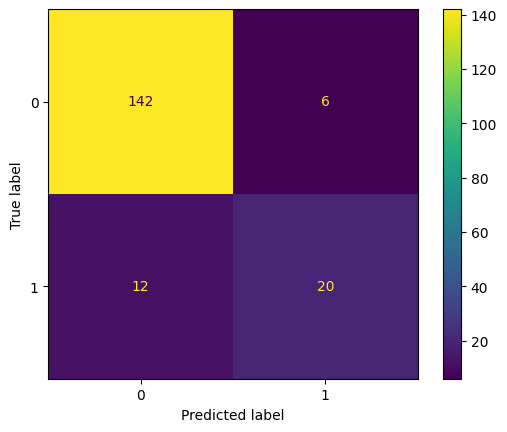

In [12]:
# Import required libraries
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv("/content/customer_churn.csv")

# Display the first 5 rows
df.head()
# 2. Removing Unwanted Columns

# Remove unnecessary columns
df = df.drop(['Names', 'Company', 'Location', 'Onboard_date'], axis=1)

# Display the first 5 rows after removing unwanted columns
df.head()
# 3. Selecting Features & Target & Splitting the Dataset

# Features and Target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Splitting the Dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
# 4. Training & Predicting

# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

# Training the Model
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

# Predicting data
y_pred = model.predict(X_test)

print(y_pred)
# 5. Displaying Confusion Matrix

# Import Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Display Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
# 6. Displaying Evaluation Metrics

# Import evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Display evaluation metrics
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
# 7. Classification Report

# Import Classification Report
from sklearn.metrics import classification_report

# Display Classification Report
print(classification_report(y_test, y_pred))
# 8. Cross Validation (5-Fold)

# Import Cross Validation
from sklearn.model_selection import cross_val_score

# Apply 5-Fold Cross Validation
cv_scores = cross_val_score(model, X, y, cv=5)

# Display Cross Validation Scores
print("Cross Validation Scores:", cv_scores)

# Display Mean Accuracy
print("Mean Accuracy:", cv_scores.mean())
# 9. Model Result

# Calculate Test Accuracy
test_accuracy = accuracy_score(y_test, y_pred)

# Calculate Cross Validation Mean Accuracy
cv_mean_accuracy = cv_scores.mean()

# Display Results
print("Test Accuracy:", round(test_accuracy, 4))
print("Cross Validation Mean Accuracy:", round(cv_mean_accuracy, 4))

# Evaluate Model Performance
if test_accuracy >= 0.90 and cv_mean_accuracy >= 0.90:
    print("\nModel Result: Best")
    print("Reason: The model achieved high accuracy on both the test data and cross-validation, indicating excellent performance and good generalization.")
elif test_accuracy >= 0.80 and cv_mean_accuracy >= 0.80:
    print("\nModel Result: Good")
    print("Reason: The model performed well with acceptable accuracy and is able to generalize reasonably on unseen data.")
else:
    print("\nModel Result: Needs Improvement")
    print("Reason: The model has relatively low accuracy or inconsistent cross-validation performance. Further feature engineering or model tuning is recommended.")